In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


In [4]:
train_dir = "splitted_dataset/train"
val_dir = "splitted_dataset/val"
test_dir = "splitted_dataset/test"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 3326 files belonging to 2 classes.
Found 476 files belonging to 2 classes.
Found 950 files belonging to 2 classes.


In [6]:
base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)
base_model.trainable = True 

In [7]:
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-50]:  
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.9380 - loss: 0.2286
Epoch 1: val_loss improved from 0.20078 to 0.17075, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 102s 886ms/step - accuracy: 0.9380 - loss: 0.2286 - val_accuracy: 0.9622 - val_loss: 0.1708
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.9468 - loss: 0.2012
Epoch 2: val_loss improved from 0.17075 to 0.14501, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 863ms/step - accuracy: 0.9468 - loss: 0.2012 - val_accuracy: 0.9685 - val_loss: 0.1450
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.9482 - loss: 0.1859
Epoch 3: val_loss improved from 0.14501 to 0.12277, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 861ms/step - accuracy: 0.9482 - loss: 0.1857 - val_accuracy: 0.9706 - val_loss: 0.1228
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.9540 - loss: 0.1636
Epoch 4: val_loss improved from 0.12277 to 0.10551, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 857ms/step - accuracy: 0.9540 - loss: 0.1636 - val_accuracy: 0.9790 - val_loss: 0.1055
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9626 - loss: 0.1392
Epoch 5: val_loss improved from 0.10551 to 0.08981, saving model to best_efficientnet_model.h5


...

104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 854ms/step - accuracy: 0.9750 - loss: 0.0884 - val_accuracy: 0.9937 - val_loss: 0.0374
Epoch 12/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9839 - loss: 0.0690
Epoch 12: val_loss improved from 0.03738 to 0.03196, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 848ms/step - accuracy: 0.9839 - loss: 0.0690 - val_accuracy: 0.9958 - val_loss: 0.0320
Epoch 13/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9790 - loss: 0.0748
Epoch 13: val_loss improved from 0.03196 to 0.02847, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 96s 926ms/step - accuracy: 0.9790 - loss: 0.0747 - val_accuracy: 0.9958 - val_loss: 0.0285
Epoch 14/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9841 - loss: 0.0640
Epoch 14: val_loss improved from 0.02847 to 0.02483, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 849ms/step - accuracy: 0.9841 - loss: 0.0640 - val_accuracy: 0.9979 - val_loss: 0.0248
Epoch 15/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9877 - loss: 0.0540
Epoch 15: val_loss improved from 0.02483 to 0.02189, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 854ms/step - accuracy: 0.9877 - loss: 0.0541 - val_accuracy: 1.0000 - val_loss: 0.0219
Restoring model weights from the end of the best epoch: 15.


In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print(f" Test Accuracy: {test_acc * 100:.2f}%")


30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 608ms/step - accuracy: 0.9984 - loss: 0.0149
 Test Accuracy: 99.79%


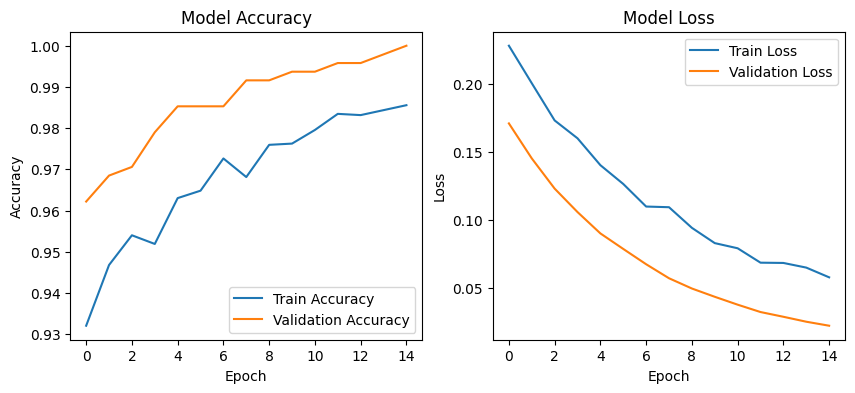

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import seaborn as sns


In [19]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()


30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 677ms/step


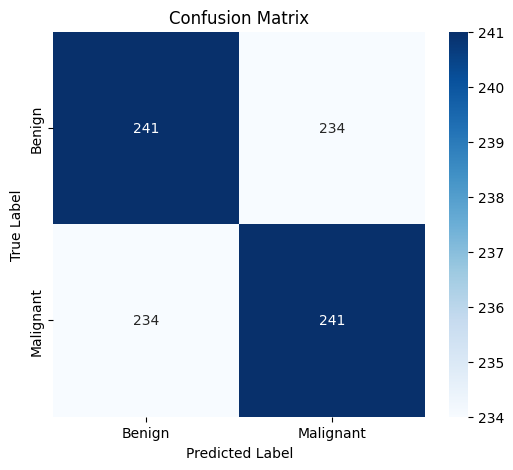

In [20]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [21]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.51      0.51      0.51       475
   Malignant       0.51      0.51      0.51       475

    accuracy                           0.51       950
   macro avg       0.51      0.51      0.51       950
weighted avg       0.51      0.51      0.51       950



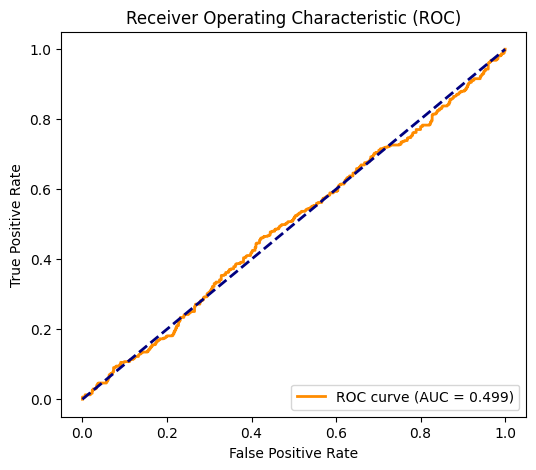

In [22]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


C:\Users\prath\AppData\Local\Temp\ipykernel_22652\513106445.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


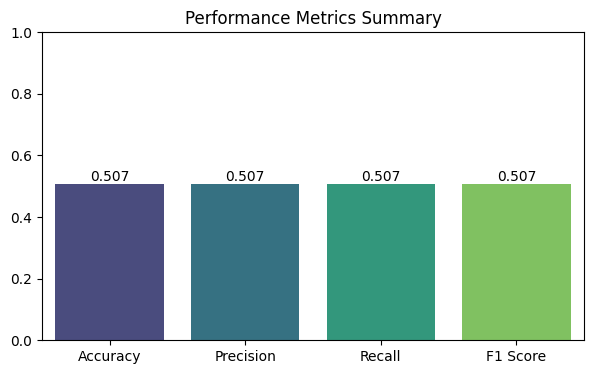

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

plt.figure(figsize=(7,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.title("Performance Metrics Summary")
plt.ylim(0,1)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()


In [33]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [476, 950]

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your dataset is split like:
# dataset/
# ├── train/
# │   ├── class1/
# │   ├── class2/
# ├── val/
# │   ├── class1/
# │   ├── class2/

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'splitted_dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'splitted_dataset/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for correct confusion matrix
)


Found 3326 images belonging to 2 classes.
Found 476 images belonging to 2 classes.


15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 613ms/step


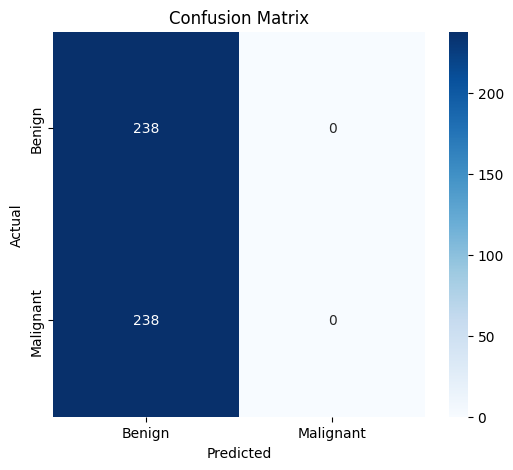

              precision    recall  f1-score   support

      Benign       0.50      1.00      0.67       238
   Malignant       0.00      0.00      0.00       238

    accuracy                           0.50       476
   macro avg       0.25      0.50      0.33       476
weighted avg       0.25      0.50      0.33       476



c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Ensure the validation generator doesn't shuffle
val_generator.shuffle = False

# Get predictions
preds = model.predict(val_generator, verbose=1)

# If binary classification, flatten the predictions
if preds.shape[1] == 1:
    y_pred = (preds > 0.5).astype(int).flatten()
else:
    y_pred = np.argmax(preds, axis=1)

y_true = val_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(val_generator.class_indices.keys()),
            yticklabels=list(val_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))


NameError: name 'finetune_history' is not defined

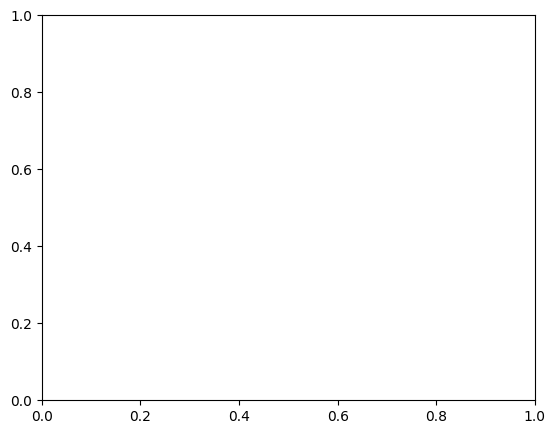

In [25]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(finetune_history.history['accuracy'], label='Train Accuracy')
plt.plot(finetune_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(finetune_history.history['loss'], label='Train Loss')
plt.plot(finetune_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Convert true labels to one-hot
y_true_bin = label_binarize(y_true, classes=range(len(val_generator.class_indices)))
y_pred_prob = model.predict(val_generator)

# For multiclass ROC
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_true_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'green', 'orange', 'red'])
plt.figure(figsize=(8,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {list(val_generator.class_indices.keys())[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.title('ROC Curve per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


NameError: name 'val_generator' is not defined